In [32]:
import sys
import pandas as pd
import glob
import numpy as np
import os
import pickle
import scipy as scp
import seaborn as sns 
import matplotlib.pyplot as plt
sys.path.append("/home/adityamoger/Documents/GitHub/dynamic_model_of_cocktail_party_nightmare/dynamic_model/")

from scores.collision_scores import compute_collision_counts_and_length
from scores.run_all_score_calculations import filter_bat_positions_from_history
from supporting_files.utilities import load_history_dump, load_parameters

In [102]:
def single_bat_collision_counts(bat_positions, parameters_df):

    # bat_positions = [i["bat_positions"] for i in history][5000:]

    arena_width = parameters_df["ARENA_WIDTH"]
    arena_length = parameters_df["ARENA_LENGTH"]
    bat_radius = parameters_df["BAT_RADIUS"]

    collision_counter = 0
    wall_collision_counter = 0
    batbat_collision_counter = 0
    # collision_duration = []
    track_collision_in_last_frame_w_bats = []
    track_collision_in_last_frame_w_walls = []
    
    store_individual_scores_wall = np.zeros(shape=(len(bat_positions), len(bat_positions[0])))
    store_individual_scores_batbat = np.zeros(shape=(len(bat_positions), len(bat_positions[0])))
    # duration_tracker = np.zeros(shape=(len(bat_positions), len(bat_positions)))

    for frame_number, position_frame in enumerate(bat_positions):
        distance_matrix = scp.spatial.distance_matrix(position_frame, position_frame)

        track_collision_in_current_frame_w_bats = []
        track_collision_in_current_frame_w_walls = []

        
        
        for i in range(distance_matrix.shape[0]):
            for j in range(distance_matrix.shape[0]):
                if i < j:
                    if distance_matrix[i, j] < 2 * bat_radius:
                        track_collision_in_current_frame_w_bats.append((i, j))
                        if (i, j) not in track_collision_in_last_frame_w_bats:
                            collision_counter += 1
                            batbat_collision_counter += 1
                            store_individual_scores_batbat[frame_number][i]+=1
                            store_individual_scores_batbat[frame_number][j]+=1
                            

        for i, bat in enumerate(position_frame):

            if (
                bat[0] >= arena_width - bat_radius
                or bat[0] <= bat_radius
                or bat[1] >= arena_length - bat_radius
                or bat[1] <= bat_radius
            ):
                track_collision_in_current_frame_w_walls.append(i)

                if i not in track_collision_in_last_frame_w_walls:
                    collision_counter += 1
                    wall_collision_counter += 1
                    store_individual_scores_wall[frame_number][i]+=1

        track_collision_in_last_frame_w_bats = track_collision_in_current_frame_w_bats
        track_collision_in_last_frame_w_walls = track_collision_in_current_frame_w_walls

    return collision_counter, wall_collision_counter, batbat_collision_counter, np.sum(store_individual_scores_wall, axis=0), np.sum(store_individual_scores_batbat, axis=0)

In [70]:
# first condense file info ngl
def given_folder_find_bat_positions(history_output_dir):
    list_of_dict_files = glob.glob(history_output_dir + "/history_dump_*.pkl")
    list_of_dict_files = np.sort(list_of_dict_files)

    list_containing_data_from_all_pickle_files = []
    for pickle_file in list_of_dict_files:
        with open(pickle_file, "rb") as f:
            _list_containing_subset = pickle.load(f)
            list_containing_data_from_all_pickle_files.extend(_list_containing_subset)

    parameter_file = glob.glob(history_output_dir + "/parameters_used.json")[0]
    parameter_df = load_parameters(parameter_file)

    times = [i["time"] for i in list_containing_data_from_all_pickle_files]
    sorting_indices = np.argsort(times)
    list_containing_data_from_all_pickle_files = np.array(
        list_containing_data_from_all_pickle_files
    )
    list_containing_data_from_all_pickle_files = list_containing_data_from_all_pickle_files[
        
        sorting_indices
    ]

    bat_positions = filter_bat_positions_from_history(
        list_containing_data_from_all_pickle_files
    )
    return bat_positions


In [ ]:
big_output_dir = "/media/adityamoger/T7 Shield/BACKUP_THESIS_DATA"
treatment_dir = big_output_dir+"/*_treatment"
null_dir = big_output_dir+"/*_null"
experiment_types = ["positive_control", "negative_control","treatment", "null", ]
group_sizes = [5,10,30,50,75,100,200]
iterations = np.arange(0,20,1)

store_scores = [("experiment_type", "group_size", "iteration", "collision_counts", "wall_collision_counts", "bat_bat_collision_counts", "duration")]

for experiment_type in experiment_types:
    for i, group_size in enumerate(group_sizes):
        for iteration in iterations:
            history_file_dir = big_output_dir+f"/*_{experiment_type}"+f"/*_{i}"+f"/*_{iteration}"
            history_file_dir = glob.glob(history_file_dir)[0]
            bat_positions = given_folder_find_bat_positions(history_file_dir)
            parameter_file = glob.glob(history_file_dir + "/parameters_used.json")[0]
            parameter_df = load_parameters(parameter_file)
            collision_counts, wall_collision_counts, bat_bat_collision_counts = compute_collision_counts_and_length(bat_positions, parameter_df)
            store_scores.append((experiment_type, group_size, iteration, collision_counts, wall_collision_counts, bat_bat_collision_counts, len(bat_positions)))
            
with open("condensed_data_0_1.pickle", "wb") as output_file:
    pickle.dump(store_scores, output_file)          

In [104]:
experiment_types = ["treatment","null", "positive_control", "negative_control"]
group_sizes = [5]
iterations = np.arange(0,20,1)
history_file_dir = big_output_dir+f"/*_{experiment_type}"+f"/*_{i}"+f"/*_{iteration}"
history_file_dir = glob.glob(history_file_dir)[0]
bat_positions = given_folder_find_bat_positions(history_file_dir)
parameter_file = glob.glob(history_file_dir + "/parameters_used.json")[0]
parameter_df = load_parameters(parameter_file)
collision_counts, wall_collision_counts, bat_bat_collision_counts, individual_scores_wall, individual_scores_batbat = single_bat_collision_counts(bat_positions, parameter_df)

individual_collision_counts_wall = []
individual_collision_counts_batbat = []
labels = []

for experiment_type in experiment_types:
    for i, group_size in enumerate(group_sizes):
        for iteration in iterations:
            history_file_dir = big_output_dir+f"/*_{experiment_type}"+f"/*_{i}"+f"/*_{iteration}"
            history_file_dir = glob.glob(history_file_dir)[0]
            
            list_of_data_files = glob.glob(history_file_dir+"/history_dump_*.pkl")
            if len(list_of_data_files)<150:
                print(experiment_type, group_size, iteration)
                break
            
            
            bat_positions = given_folder_find_bat_positions(history_file_dir)
            parameter_file = glob.glob(history_file_dir + "/parameters_used.json")[0]
            parameter_df = load_parameters(parameter_file)
            
            
            collision_counts, wall_collision_counts, bat_bat_collision_counts, individual_scores_wall, individual_scores_batbat = single_bat_collision_counts(bat_positions, parameter_df)
            
            label = [experiment_type]*len(individual_scores_wall)
            individual_collision_counts_wall.extend(individual_scores_wall)
            individual_collision_counts_batbat.extend(individual_scores_batbat)
            labels.extend(label)
            store_scores.append((experiment_type, group_size, iteration, collision_counts, wall_collision_counts, bat_bat_collision_counts))
            # print(individual_collision_counts_batbat)

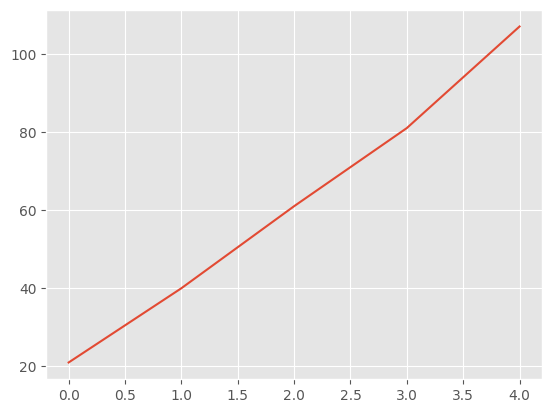

In [105]:
plt.plot(np.cumsum(individual_scores_wall, axis=0))
plt.show()

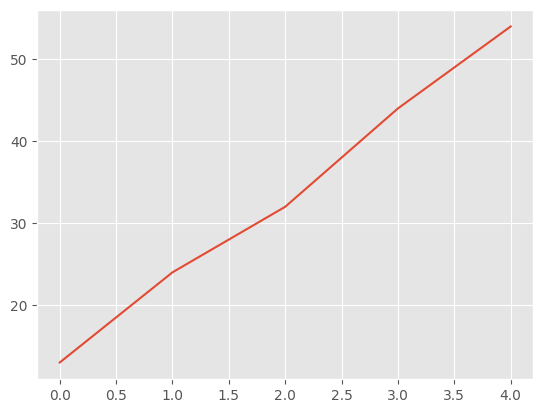

In [106]:
plt.plot(np.cumsum(individual_scores_batbat, axis=0))
plt.show()

In [68]:
np.sum(individual_scores_wall, axis =0)

array([15., 15., 10., 13., 15., 10.,  9., 16., 12., 14., 14., 15., 13.,
        9., 13., 13., 14., 12., 15., 13., 14., 14., 10.,  9., 13., 10.,
       12., 13., 14., 14.])

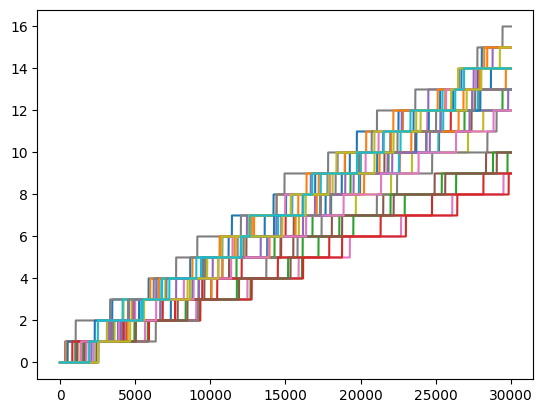

In [61]:
plt.plot(np.cumsum(individual_scores_wall, axis=0))
plt.show()

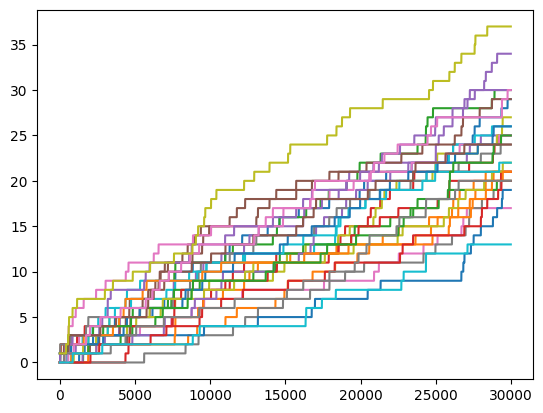

In [62]:
plt.plot(np.cumsum(individual_scores_batbat, axis=0))
plt.show()

In [37]:
len(individual_scores_wall)

25000

In [ ]:

            # bat_positions = given_folder_find_bat_positions(history_file_dir)
            # parameter_file = glob.glob(history_file_dir + "/parameters_used.json")[0]
            # parameter_df = load_parameters(parameter_file)
            # collision_counts, wall_collision_counts, bat_bat_collision_counts = compute_collision_counts_and_length(bat_positions, parameter_df)
            # store_scores.append((experiment_type, group_size, iteration, collision_counts, wall_collision_counts, bat_bat_collision_counts))

treatment 75 9
treatment 75 12
treatment 200 1
treatment 200 7
treatment 200 10
treatment 200 12
treatment 200 13
positive_control 30 17
positive_control 75 8
positive_control 75 19
positive_control 100 4
positive_control 100 6
positive_control 100 7
positive_control 100 10
positive_control 100 18
positive_control 200 1
positive_control 200 2
positive_control 200 8
negative_control 10 16
negative_control 50 7
negative_control 75 6
negative_control 75 8
negative_control 100 6
negative_control 100 10
negative_control 100 14
negative_control 200 0
negative_control 200 1
negative_control 200 5
negative_control 200 14
negative_control 200 15


In [75]:
len(list_of_data_files)

150

In [134]:
store_scores

[('experiment_type',
  'group_size',
  'iteration',
  'collision_counts',
  'wall_collision_counts',
  'bat_bat_collision_counts',
  'duration'),
 ('positive_control', 5, np.int64(0), 59, 34, 25, 30000),
 ('positive_control', 5, np.int64(1), 55, 28, 27, 30000),
 ('positive_control', 5, np.int64(2), 68, 36, 32, 30000),
 ('positive_control', 5, np.int64(3), 58, 27, 31, 30000),
 ('positive_control', 5, np.int64(4), 56, 27, 29, 30000),
 ('positive_control', 5, np.int64(5), 54, 27, 27, 30000),
 ('positive_control', 5, np.int64(6), 66, 30, 36, 30000),
 ('positive_control', 5, np.int64(7), 54, 26, 28, 30000),
 ('positive_control', 5, np.int64(8), 64, 32, 32, 30000),
 ('positive_control', 5, np.int64(9), 56, 25, 31, 30000),
 ('positive_control', 5, np.int64(10), 53, 23, 30, 30000),
 ('positive_control', 5, np.int64(11), 53, 31, 22, 30000),
 ('positive_control', 5, np.int64(12), 59, 29, 30, 30000),
 ('positive_control', 5, np.int64(13), 56, 27, 29, 30000),
 ('positive_control', 5, np.int64(14),

In [135]:
df = pd.DataFrame(store_scores[1:], columns= store_scores[0])
df

,experiment_type,group_size,iteration,collision_counts,wall_collision_counts,bat_bat_collision_counts,duration
0,positive_control,5,0,59,34,25,30000
1,positive_control,5,1,55,28,27,30000
2,positive_control,5,2,68,36,32,30000
3,positive_control,5,3,58,27,31,30000
4,positive_control,5,4,56,27,29,30000
...,...,...,...,...,...,...,...
555,null,200,15,4236,1192,3044,30000
556,null,200,16,4275,1197,3078,30000
557,null,200,17,4176,1181,2995,30000
558,null,200,18,4240,1184,3056,30000


In [156]:
big_output_dir = "/media/adityamoger/T7 Shield/BACKUP_THESIS_DATA"
treatment_dir = big_output_dir+"/*_treatment"
null_dir = big_output_dir+"/*_null"
experiment_types = ["treatment", "null", "positive_control", "negative_control"]
group_sizes = [5,10,30,50,75,100,200]
iterations = np.arange(0,20,1)

store_scores = [("experiment_type", "group_size", "iteration", "collision_counts", "wall_collision_counts", "bat_bat_collision_counts")]
df_copy = df.copy()
for experiment_type in experiment_types:
    for i, group_size in enumerate(group_sizes):
        for iteration in iterations:
            history_file_dir = big_output_dir+f"/*_{experiment_type}"+f"/*_{i}"+f"/*_{iteration}"
            # print(history_file_dir)
            history_file_dir = glob.glob(history_file_dir)[0]
            list_of_data_files = glob.glob(history_file_dir+"/history_dump_*.pkl")
            if len(list_of_data_files)<150:
                print(experiment_type, group_size, iteration)
                df_copy = df_copy.loc[~((df_copy["experiment_type"]==experiment_type) & (df_copy["group_size"]==group_size) & (df_copy["iteration"] ==iteration))]
                

treatment 75 9
treatment 75 12
treatment 200 1
treatment 200 7
treatment 200 10
treatment 200 12
treatment 200 13
positive_control 30 17
positive_control 75 8
positive_control 75 19
positive_control 100 4
positive_control 100 6
positive_control 100 7
positive_control 100 10
positive_control 100 18
positive_control 200 1
positive_control 200 2
positive_control 200 8
negative_control 10 16
negative_control 50 7
negative_control 75 6
negative_control 75 8
negative_control 100 6
negative_control 100 10
negative_control 100 14
negative_control 200 0
negative_control 200 1
negative_control 200 5
negative_control 200 14
negative_control 200 15


In [153]:
(df_copy["experiment_type"]==experiment_type) & (df_copy["group_size"]!=group_size) & (df_copy["iteration"]!=iteration)

420    False
421    False
422    False
423    False
424    False
       ...  
555    False
556    False
557    False
558    False
559    False
Length: 140, dtype: bool

In [158]:
len(df_copy)
len(df)

560

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

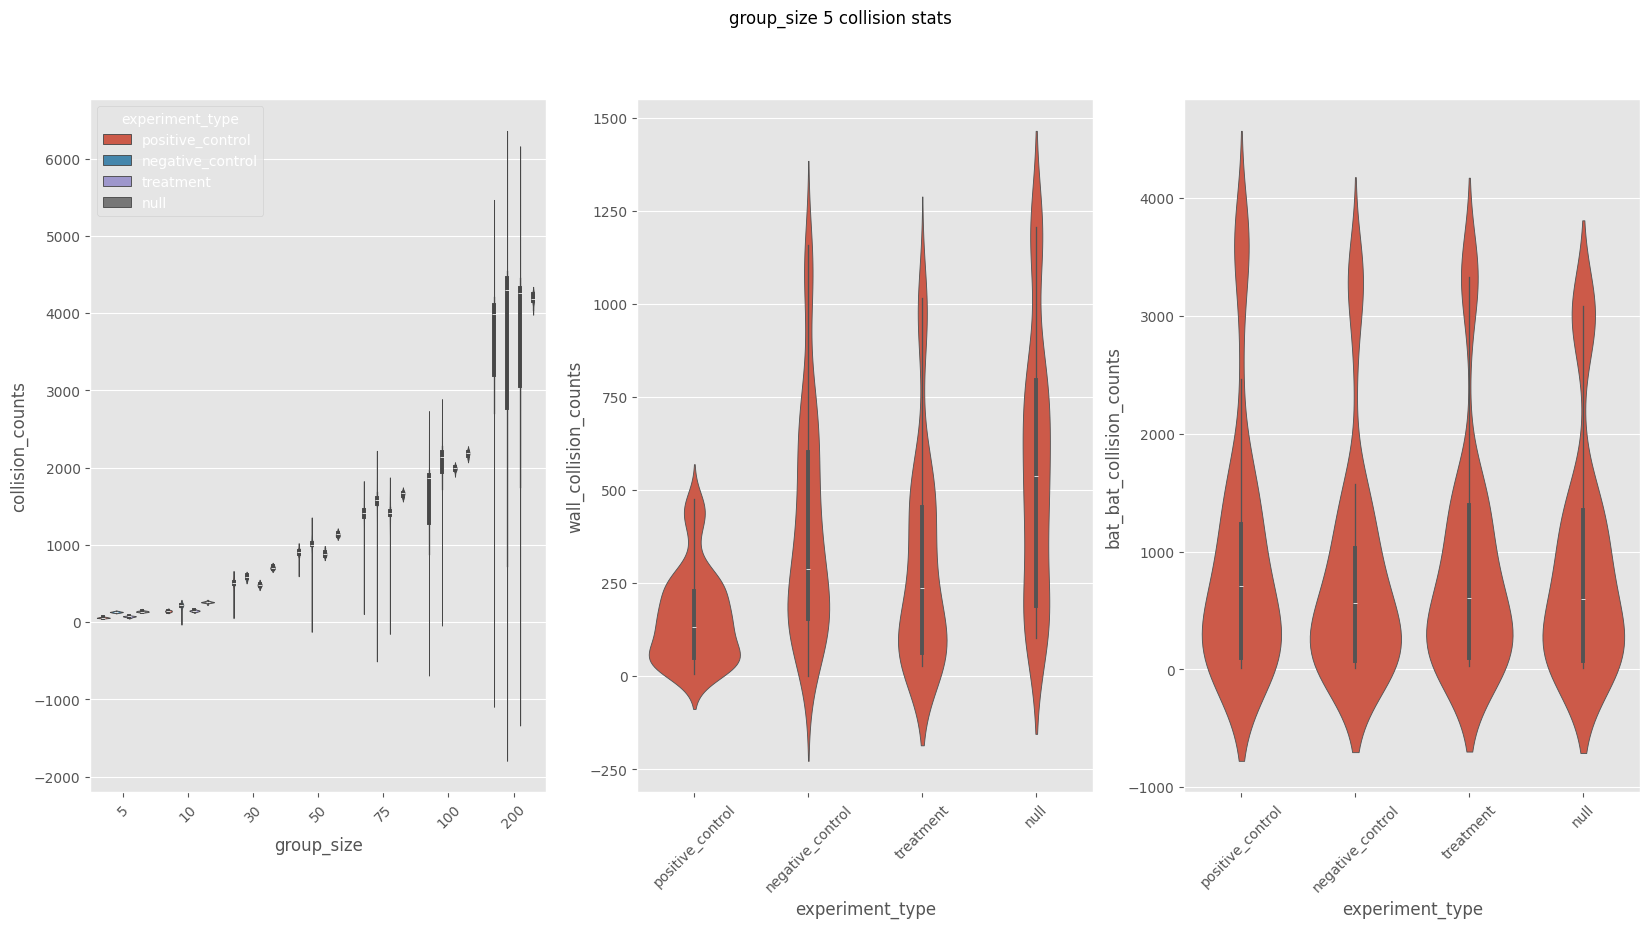

In [159]:
plt.figure(figsize=(20,9))
plt.subplot(1,3,1)
sns.violinplot(df, y="collision_counts", hue="experiment_type", x="group_size")
# plt.ylim(0,180)
plt.xticks(rotation=45)
plt.subplot(1,3,2)
sns.violinplot(df, y="wall_collision_counts", x="experiment_type")
# plt.ylim(0,180)
plt.xticks(rotation=45)
plt.subplot(1,3,3)
sns.violinplot(df, y="bat_bat_collision_counts", x="experiment_type")
# plt.ylim(0,180)
plt.xticks(rotation=45)
plt.suptitle("group_size 5 collision stats", color="black")
plt.show()

<Axes: xlabel='group_size', ylabel='collision_counts'>

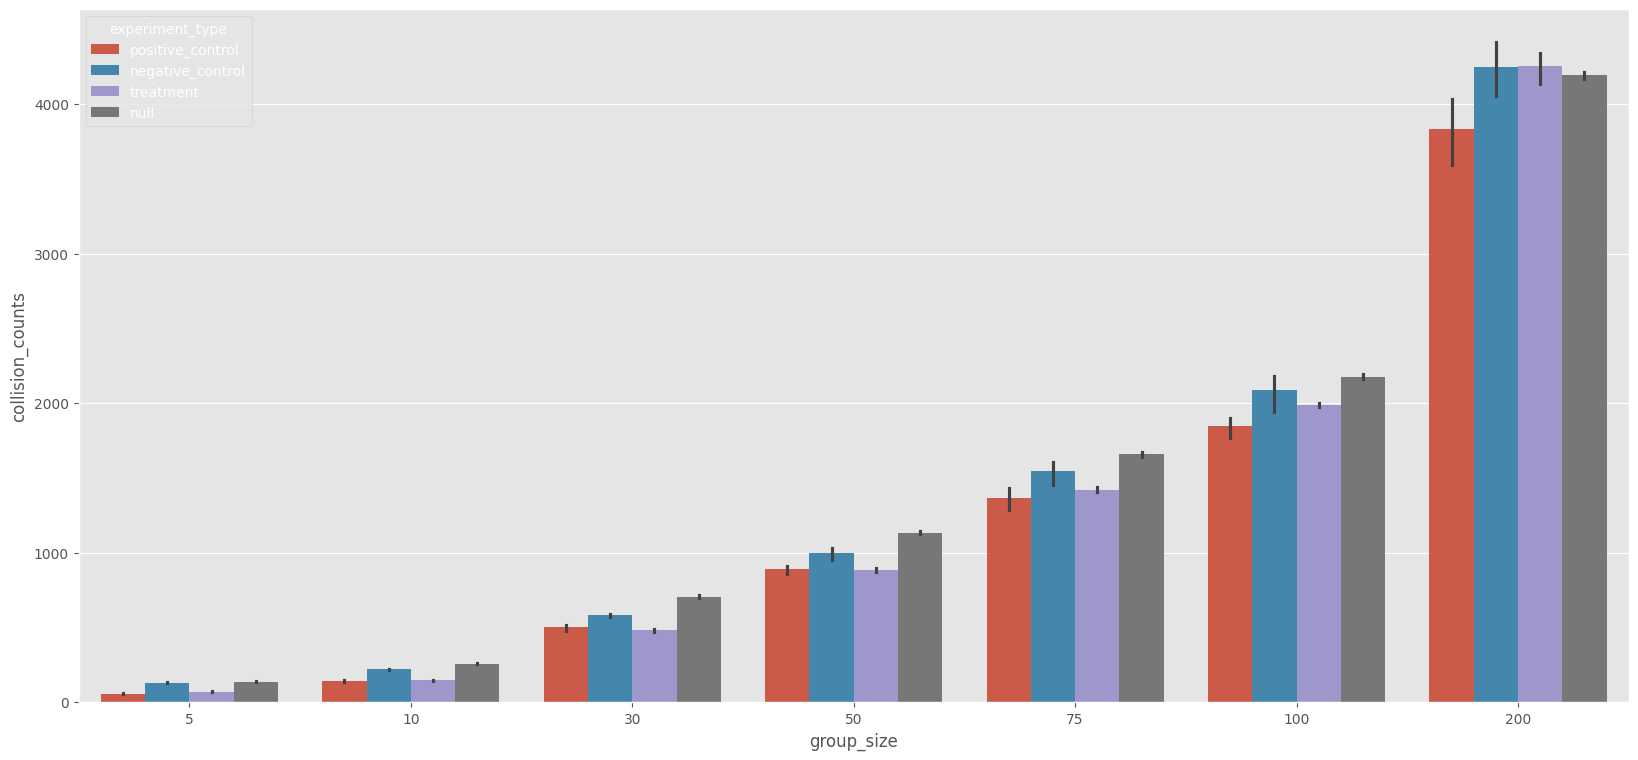

In [174]:
plt.figure(figsize=(20,9))
# plt.subplot(1,3,1)
sns.barplot(df_copy, y="collision_counts", hue="experiment_type", x="group_size")

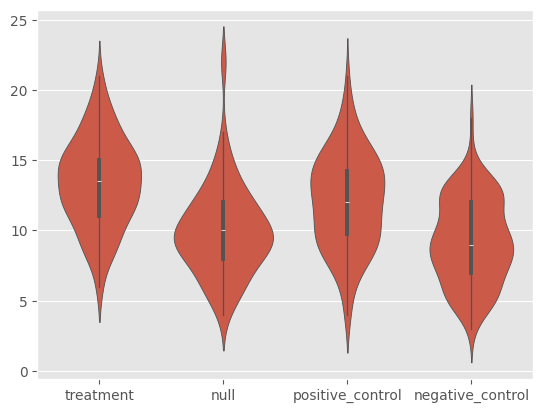

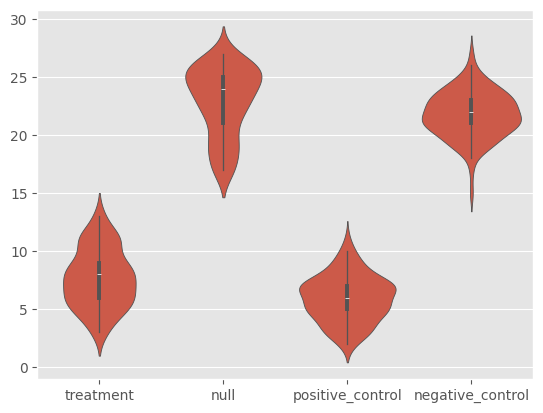

<Axes: >

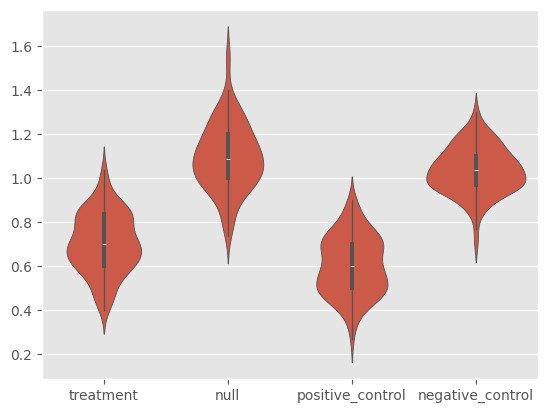

In [173]:
sns.violinplot(x=labels, y=individual_collision_counts_batbat)
plt.show()
sns.violinplot(x=labels, y=np.array(individual_collision_counts_wall))
plt.show()
z= (np.array(individual_collision_counts_batbat) + np.array(individual_collision_counts_wall))/30
sns.violinplot(x=labels, y=z)

<Axes: ylabel='wall_collision_counts'>

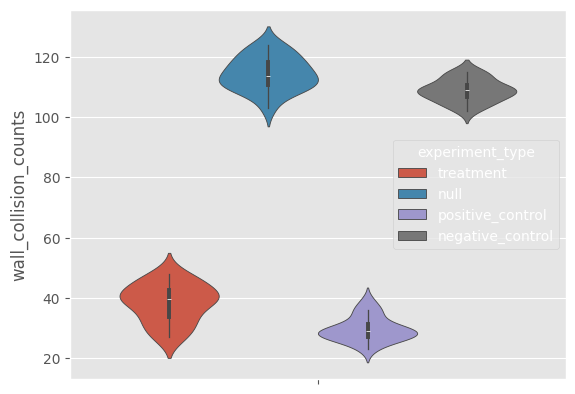

In [91]:
sns.violinplot(df, y="wall_collision_counts", hue="experiment_type")

<Axes: xlabel='group_size', ylabel='bat_bat_collision_counts'>

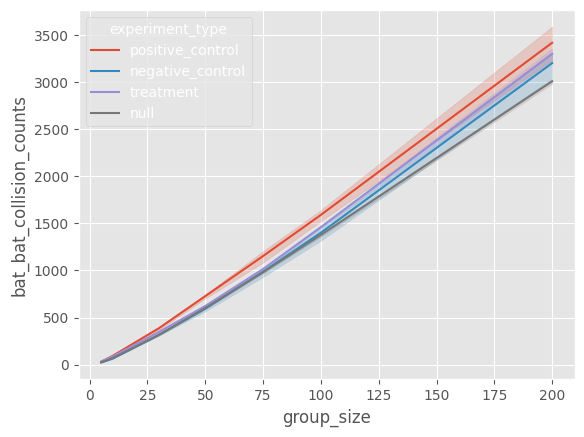

In [172]:
sns.lineplot(df, x="group_size", y="bat_bat_collision_counts", hue="experiment_type")

In [163]:
df["collision_counts_scaled"] = df["collision_counts"]/(df["group_size"])
df["wall_collision_counts_scaled"] = df["wall_collision_counts"]/df["group_size"]
df["bat_bat_collision_counts_scaled"] = df["bat_bat_collision_counts"]/df["group_size"]

Text(0, 0.5, 'collision_counts / group_size')

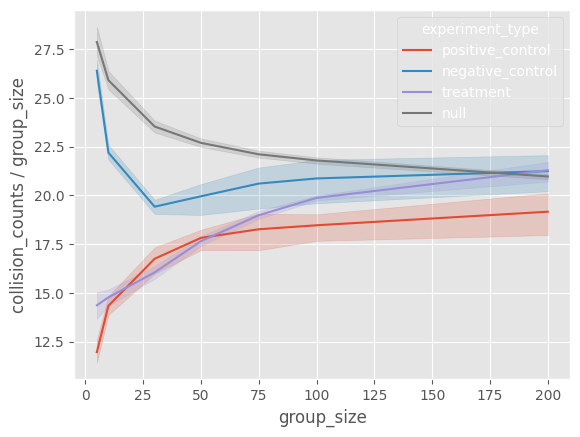

In [175]:
sns.lineplot(df, x="group_size", y="collision_counts_scaled", hue="experiment_type")
plt.ylabel("collision_counts / group_size")

Text(0, 0.5, 'wall_collision_counts / group_size')

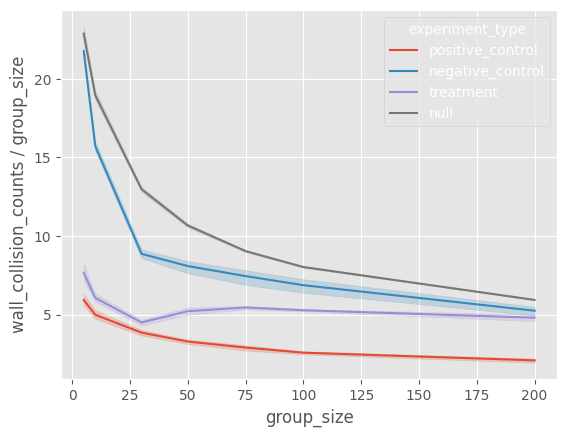

In [176]:
sns.lineplot(df, x="group_size", y="wall_collision_counts_scaled", hue="experiment_type")
plt.ylabel("wall_collision_counts / group_size")

Text(0, 0.5, 'bat bat collision_counts / group_size')

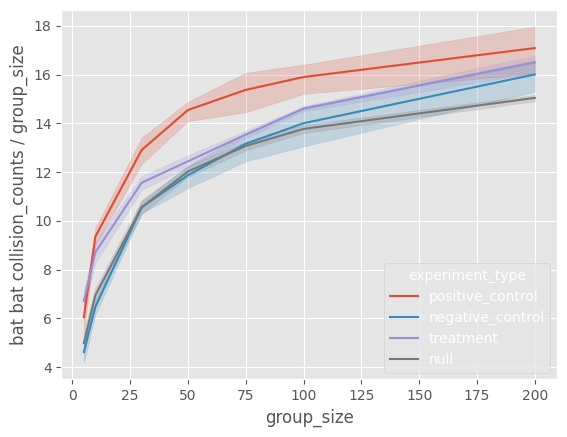

In [177]:
sns.lineplot(df, x="group_size", y="bat_bat_collision_counts_scaled", hue="experiment_type")
plt.ylabel("bat bat collision_counts / group_size")